# Agile Data Science PMA

## Predictive Modelling of Engineer Response Time Using Machine Learning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
plt.style.use("ggplot")

# Show all columns
pd.set_option('display.max_columns', None)

# Q1 Dataset Preparation

## 1.1 Dataset Overview

In [3]:
df = pd.read_csv("../data/mp2_dataset.csv", low_memory=False)

In [4]:
df.head()

,Admin TAT BD,Business Segment,Business Sub Type,Business Type,Calendar Month,Cc Tat Bd,Cdax Business Segment,Closed Date Ltz,Country Code,Delivery,Delivery Alternative,Delivery Motion,First Onsite Actual Start Time Date Ltz,Dispatch Tat Db,First Part Ordered Date Ltz,First Ready For Dispatch Date Ltz,First Wo Dispatched Date Ltz,Hpce Activer Resource Fwo,Hwpl,Case Id,Incident Type,Incoming Channel,Last Fixed On Date Date Ltz,Logistics Tat Db,Market Segment,Multiple Interventions Flag,Opened Date Ltz,Order Type,Otc Code,Parts Fullfilment Tat Db,Product,Fix Tat Bd,Response Tat Bd,Response end,Serial Number,E2E Resolution BD,Field Tat BD,Supply Chain Tat BD,Admin Tat Distribution,Cc Tat Distribution,Month,Week,Dispatch Tat Distribution,E2E Sit Tat Distribution,Fix Tat Distribution,Response Tat Distribution,Field Tat Distribution,Supply Chain Tat Distribution,Troubleshooting Tat Distribution,Caseid Count,Field Ola Target,Field Ola Met Flag,Troubleshooting Tat Bd,Zip Code,Sub Reg1,Sub Reg2,Sub Reg3,Country,Delay Code Categ,Order Type Category,Rdt Tat Bd,Service Offer Identifier,Delay Code,Supplier,Active Resourse Blanks,Hpce Area Leader,Hpce District Leader,First Valid Wo Id,Service Flag,Customer Account Name,Customer Name,Owned By Site Name,Product Category Name,Incoming Channel Categ,Global Business Unit,Otc Code Categ,Last Expected Delivery Date Ltz,Last Promised Date Ltz,Last Expected Delivery Date Ltz.1,Last Actual Ship Date Ltz,Last Carrier Drop Date Customer,Cdax Last Actual Pudo Pick Up Date Ltz,Last Actual Delivery Date Ltz,Time Zone,Sit 5Bd Flag,Sit 10Bd Flag,Field Ola 2Bd Flag,Field Ola 3Bd Flag,Field Ola Sbd Flag,Card Account Name,Response Nbd Ola,Ppmd Flag,Pod Shipmentid,Pudo Shipmentid,Field Contractual Ola Met Flag,Response Contractual Ola Met Flag,Ccc Nbd Ola Met Flag,Ssc 3Bd Ola Met Flag,Ssc Nbd Ola Met Flag,Fix 3Bd Ola Met Flag,Fix Nbd Ola Met Flag,Supply Chain Tat Bd 12,Supply Chain Tat Bd 16,INX Sales Order Header Create Date Ltz,INX Last Part Pod Date Ltz New,CCC end,CCC start,Response start,Response end.1,Fix end,Fix start,Admin end,Admin start,Troubleshooting start,Troubleshooting end,SCC start,SCC end,SCC end 12,SCC end 14,SCC end 16,Dispatch start,Dispatch end,Parts fulfillment start,Parts fulfillment end,Logistics start,Logistics end,Field start,Field end,RDT start,RDT end,I Last Pudo Ready For Pick Up Date Ltz,E2E start,E2E end,First Touched Date Case,Field Contr start,Field Contr TAT BD,Response CT start,Response CT TAT BD,First Touched Agent Name Case,Last Part Ship Plant,Last Part Order Number,First Part Ship Plant,First Part Order Number,State,Field Ops Territory,Product Description,Product Category Resume,Account Tier,Wo Count
0,33,Printing,Transactional,Transactional,202504.0,0.0,Printing,4/16/2025 22:29:54,MY,Onsite,HP CE Onsite,Onsite,2/26/2025 15:00:00,0.0,2/21/2025 13:16:55,2/21/2025 13:17:59,2/21/2025 13:45:30,MOHAMAD KARIMI BIN HAMAT SHAFIE,30,5.138882e+09,Print Problem-APJ-Printing,Phone,2/26/2025 16:00:00,1.0,Commercial,0.0,2/21/2025 12:56:54,Break Fix,05K-Extended Warranty,0.0,2Y9H3A,0.0,3.0,2/26/2025 15:00:00,CN3BD3M051,3.0,2.0,1.0,5BD+,SBD,25-04,25w16,SBD,3BD,SBD,3BD,2BD,NBD,SBD,1.0,2.0,1.0,0.0,18300,Greater Asia,South East Asia,Malaysia Brunei,Malaysia,Customer,Break_Fix,1.0,WOSFF0,8-Customer caused Delay,Peopleworks IT Services,1.0,NaN,NaN,WO-029221210,NBD,LLC Infra Sdn Bhd,LLC Infra Sdn Bhd,HP SubK Singapore (APJ),HP DesignJet Large Format Printers,Phone,Large Format,05K-Extend_Wty,2/21/2025 08:00:00,2/24/2025 16:00:00,2/21/2025 08:00:00,2/21/2025 08:00:00,NaN,NaN,NaN,"(GMT+08:00) Kuala Lumpur, Singapore",1.0,1.0,1.0,1.0,0.0,NaN,0.0,1.0,3.012886e+09,NaN,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2/21/2025 13:47:20,2/23/2025 09:30:00,2/21/2025 12:56:54,2/21/2025 13:45:30,2/21/2025 13:45:30,2/26/2025 15:00:00,2/26/2025 15:00:00,2/26/2025 16:00:00,2/26/2025 16:00:00,4/16/2025 22:29:54,2/21/2025 12:56:54,2/21/2025 13:17:59,2/21/2025 13:47:20,2/24/2025 08:00:00,2/24/2025 08:00:00,2/24/2025 08:00:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10544 entries, 0 to 10543
Columns: 149 entries, Admin TAT BD to Wo Count
dtypes: float64(42), object(107)
memory usage: 12.0+ MB


In [6]:
df.describe(include='all')

,Admin TAT BD,Business Segment,Business Sub Type,Business Type,Calendar Month,Cc Tat Bd,Cdax Business Segment,Closed Date Ltz,Country Code,Delivery,Delivery Alternative,Delivery Motion,First Onsite Actual Start Time Date Ltz,Dispatch Tat Db,First Part Ordered Date Ltz,First Ready For Dispatch Date Ltz,First Wo Dispatched Date Ltz,Hpce Activer Resource Fwo,Hwpl,Case Id,Incident Type,Incoming Channel,Last Fixed On Date Date Ltz,Logistics Tat Db,Market Segment,Multiple Interventions Flag,Opened Date Ltz,Order Type,Otc Code,Parts Fullfilment Tat Db,Product,Fix Tat Bd,Response Tat Bd,Response end,Serial Number,E2E Resolution BD,Field Tat BD,Supply Chain Tat BD,Admin Tat Distribution,Cc Tat Distribution,Month,Week,Dispatch Tat Distribution,E2E Sit Tat Distribution,Fix Tat Distribution,Response Tat Distribution,Field Tat Distribution,Supply Chain Tat Distribution,Troubleshooting Tat Distribution,Caseid Count,Field Ola Target,Field Ola Met Flag,Troubleshooting Tat Bd,Zip Code,Sub Reg1,Sub Reg2,Sub Reg3,Country,Delay Code Categ,Order Type Category,Rdt Tat Bd,Service Offer Identifier,Delay Code,Supplier,Active Resourse Blanks,Hpce Area Leader,Hpce District Leader,First Valid Wo Id,Service Flag,Customer Account Name,Customer Name,Owned By Site Name,Product Category Name,Incoming Channel Categ,Global Business Unit,Otc Code Categ,Last Expected Delivery Date Ltz,Last Promised Date Ltz,Last Expected Delivery Date Ltz.1,Last Actual Ship Date Ltz,Last Carrier Drop Date Customer,Cdax Last Actual Pudo Pick Up Date Ltz,Last Actual Delivery Date Ltz,Time Zone,Sit 5Bd Flag,Sit 10Bd Flag,Field Ola 2Bd Flag,Field Ola 3Bd Flag,Field Ola Sbd Flag,Card Account Name,Response Nbd Ola,Ppmd Flag,Pod Shipmentid,Pudo Shipmentid,Field Contractual Ola Met Flag,Response Contractual Ola Met Flag,Ccc Nbd Ola Met Flag,Ssc 3Bd Ola Met Flag,Ssc Nbd Ola Met Flag,Fix 3Bd Ola Met Flag,Fix Nbd Ola Met Flag,Supply Chain Tat Bd 12,Supply Chain Tat Bd 16,INX Sales Order Header Create Date Ltz,INX Last Part Pod Date Ltz New,CCC end,CCC start,Response start,Response end.1,Fix end,Fix start,Admin end,Admin start,Troubleshooting start,Troubleshooting end,SCC start,SCC end,SCC end 12,SCC end 14,SCC end 16,Dispatch start,Dispatch end,Parts fulfillment start,Parts fulfillment end,Logistics start,Logistics end,Field start,Field end,RDT start,RDT end,I Last Pudo Ready For Pick Up Date Ltz,E2E start,E2E end,First Touched Date Case,Field Contr start,Field Contr TAT BD,Response CT start,Response CT TAT BD,First Touched Agent Name Case,Last Part Ship Plant,Last Part Order Number,First Part Ship Plant,First Part Order Number,State,Field Ops Territory,Product Description,Product Category Resume,Account Tier,Wo Count
count,8209,8207,8207,8207,8207.000000,8207.000000,8207,8207,8207,8207,8207,8207,8207,8170.000000,8067,6387,8207,8207,8114,8.207000e+03,8207,8207,8207,7861.000000,8207,8207.000000,8207,8207,8207,7960.000000,8207,8207.000000,8207.000000,8207,8207,8207.000000,7968.000000,7968.000000,8207,8207,8207,8207,8170,8207,8207,8207,7968,7968,8170,8208.000000,8207.000000,7968.000000,8170.000000,8205,8207,8207,8207,8207,8207,8207,8207.000000,8207,8207,8207,8207.0,0.0,0.0,8207,8207,6640,8198,8207,8207,8207,8114,8207,8070,7826,8069,8068,2,216,6046,8191,8207.000000,8207.000000,7968.000000,7968.000000,7968.000000,22,8207.000000,8207.000000,7.968000e+03,0.0,7968.000000,8207.000000,8207.000000,7968.000000,7968.000000,8207.000000,8207.000000,7968.000000,7968.000000,7968,7968,8207,8207,8207,8207,8207,8207,8207,8207,8207,8170,7968,7968,7968,7968,7968,8170,8207,8067,7961,7961,7968,7968,8207,8207,8207,0.0,8207,8207,8207,7968,7968.000000,8207,8207.000000,8207,7968,7968,7968,7968,22,6511,8207,8207,2481,8207.000000
unique,53,2,5,2,NaN,NaN,3,8207,1,1,2,1,4933,NaN,8062,6384,8199,99,37,NaN,10,9,5333,NaN,2,NaN,8200,4,2,NaN,1265,NaN,NaN,4808,7833,NaN,NaN,NaN,6,6,6,27,6,8,6,6,6,6,6,NaN,NaN,NaN,NaN,526,1,1,1,1,5,2,NaN,7,8,1,NaN,NaN,NaN,8207,3,2219,3416,4,16,4,11,2,457,179,171,6114,2,34,620,7,NaN,NaN,NaN,NaN,NaN,

In [42]:
print("="*50)
print("Dataset Dimensions")
print("="*50)

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Dataset Dimensions
Number of rows    : 10544
Number of columns : 149


In [41]:
print(df.columns.tolist())

['Admin TAT BD', 'Business Segment', 'Business Sub Type', 'Business Type', 'Calendar Month', 'Cc Tat Bd', 'Cdax Business Segment', 'Closed Date Ltz', 'Country Code', 'Delivery', 'Delivery Alternative', 'Delivery Motion', 'First Onsite Actual Start Time Date Ltz', 'Dispatch Tat Db', 'First Part Ordered Date Ltz', 'First Ready For Dispatch Date Ltz', 'First Wo Dispatched Date Ltz', 'Hpce Activer Resource Fwo', 'Hwpl', 'Case Id', 'Incident Type', 'Incoming Channel', 'Last Fixed On Date Date Ltz', 'Logistics Tat Db', 'Market Segment', 'Multiple Interventions Flag', 'Opened Date Ltz', 'Order Type', 'Otc Code', 'Parts Fullfilment Tat Db', 'Product', 'Fix Tat Bd', 'Response Tat Bd', 'Response end', 'Serial Number', 'E2E Resolution BD', 'Field Tat BD', 'Supply Chain Tat BD', 'Admin Tat Distribution', 'Cc Tat Distribution', 'Month', 'Week', 'Dispatch Tat Distribution', 'E2E Sit Tat Distribution', 'Fix Tat Distribution', 'Response Tat Distribution', 'Field Tat Distribution', 'Supply Chain Tat Di

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Pudo Shipmentid                           10544
Hpce Area Leader                          10544
Hpce District Leader                      10544
I Last Pudo Ready For Pick Up Date Ltz    10544
Last Carrier Drop Date Customer           10542
                                          ...  
E2E Sit Tat Distribution                   2337
Week                                       2337
Month                                      2337
Caseid Count                               2336
Admin TAT BD                               2335
Length: 149, dtype: int64

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 2334


In [16]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")

print(f"\nNumerical Columns : {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical Columns : {len(df.select_dtypes(include='object').columns)}")

DATASET INFORMATION
Rows      : 10544
Columns   : 149

Numerical Columns : 42
Categorical Columns : 107


In [17]:
target = "Response Tat Bd"

print("Target Variable :", target)

Target Variable : Response Tat Bd


## 1.2 Exploratory Data Analysis (EDA)

### Distribution Analysis

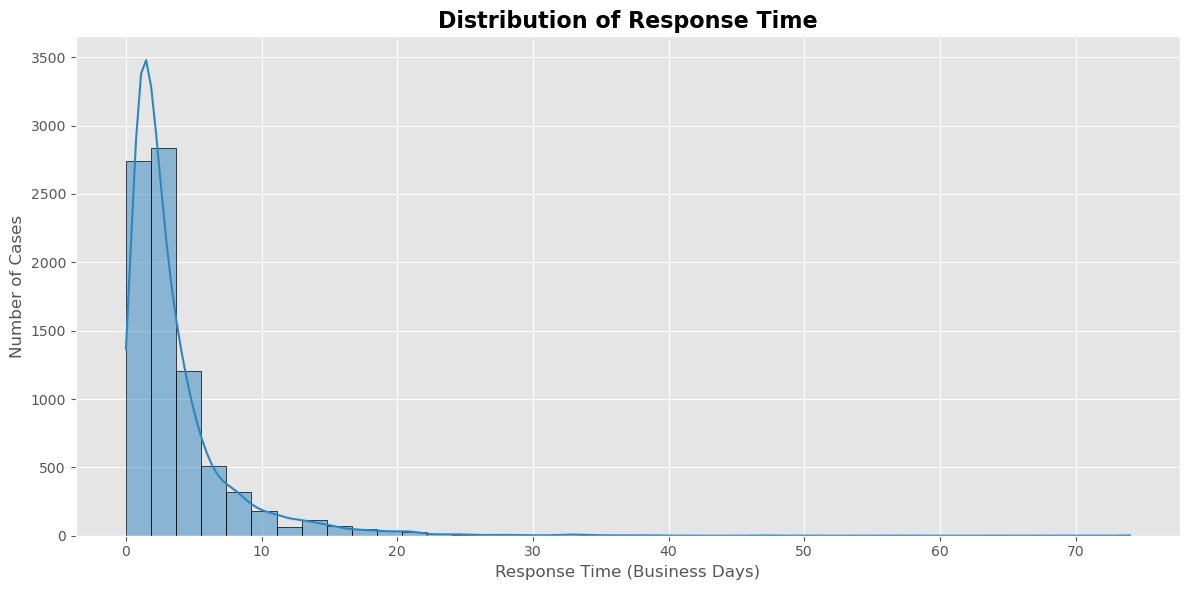

In [19]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Response Tat Bd"],
    bins=40,
    color="#2E86C1",
    edgecolor="black",
    kde=True
)

plt.title("Distribution of Response Time", fontsize=16, fontweight='bold')
plt.xlabel("Response Time (Business Days)", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)

plt.tight_layout()

plt.show()

### Observation

The distribution of Response Tat Bd is positively skewed. Most service requests were responded to within 1–5 business days. However, a small proportion of cases required substantially longer response times, indicating the presence of outliers and operational variability.

### Categorical Analysis

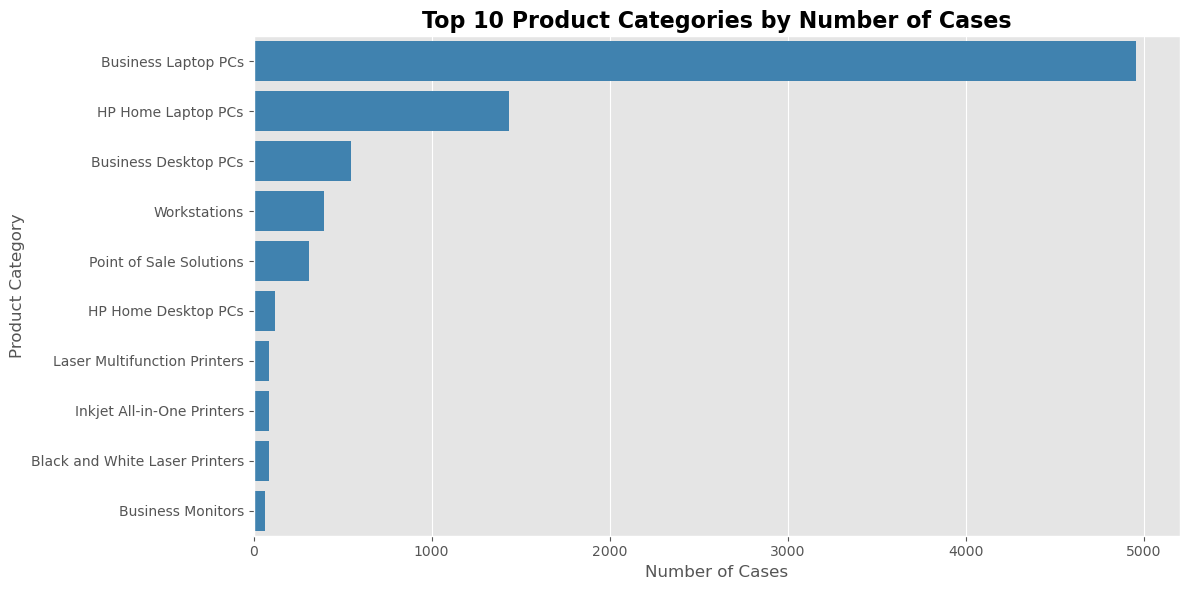

In [23]:
# Top 10 Product Categories
top_category = (
    df["Product Category Name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_category.values,
    y=top_category.index,
    color="#2E86C1"
)

plt.title("Top 10 Product Categories by Number of Cases",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Cases", fontsize=12)
plt.ylabel("Product Category", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

Business Laptop PCs account for the highest number of service cases, followed by HP Home Laptop PCs and Business Desktop PCs. This suggests that laptop-related products contribute the majority of service demand within the dataset.



In [27]:
for col in tat_columns:
    print(f"{col}: {df[col].dtype}")

Admin TAT BD: object
Cc Tat Bd: float64
Dispatch Tat Db: float64
Logistics Tat Db: float64
Parts Fullfilment Tat Db: float64
Response Tat Bd: float64
Fix Tat Bd: float64
Field Tat BD: float64
Supply Chain Tat BD: float64
Troubleshooting Tat Bd: float64
Rdt Tat Bd: float64
E2E Resolution BD: float64


In [28]:
for col in tat_columns:
    if df[col].astype(str).str.contains("Total", case=False, na=False).any():
        print(f"'Total' found in: {col}")

'Total' found in: Admin TAT BD


In [29]:
for col in tat_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [30]:
corr = df[tat_columns].corr()

### Relationship Analysis

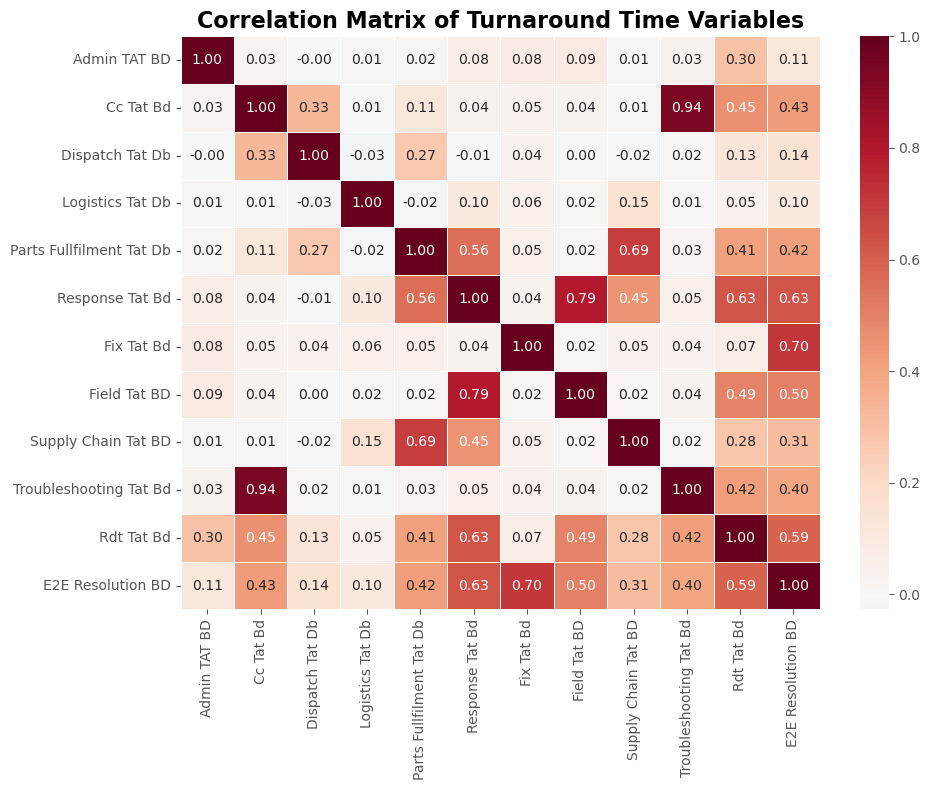

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Turnaround Time Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Observation

The correlation analysis indicates several moderate to strong positive relationships among the turnaround time (TAT) variables.

Response Tat Bd shows a strong positive correlation with Field Tat BD (r = 0.79), suggesting that longer engineer response times are generally associated with longer field service durations. In addition, E2E Resolution BD demonstrates a strong relationship with Fix Tat Bd (r = 0.70), indicating that repair duration contributes substantially to the overall end-to-end resolution time.

These findings suggest that multiple operational turnaround stages are interrelated and may influence the prediction of engineer response time.

## 1.3 Data Quality Assessment

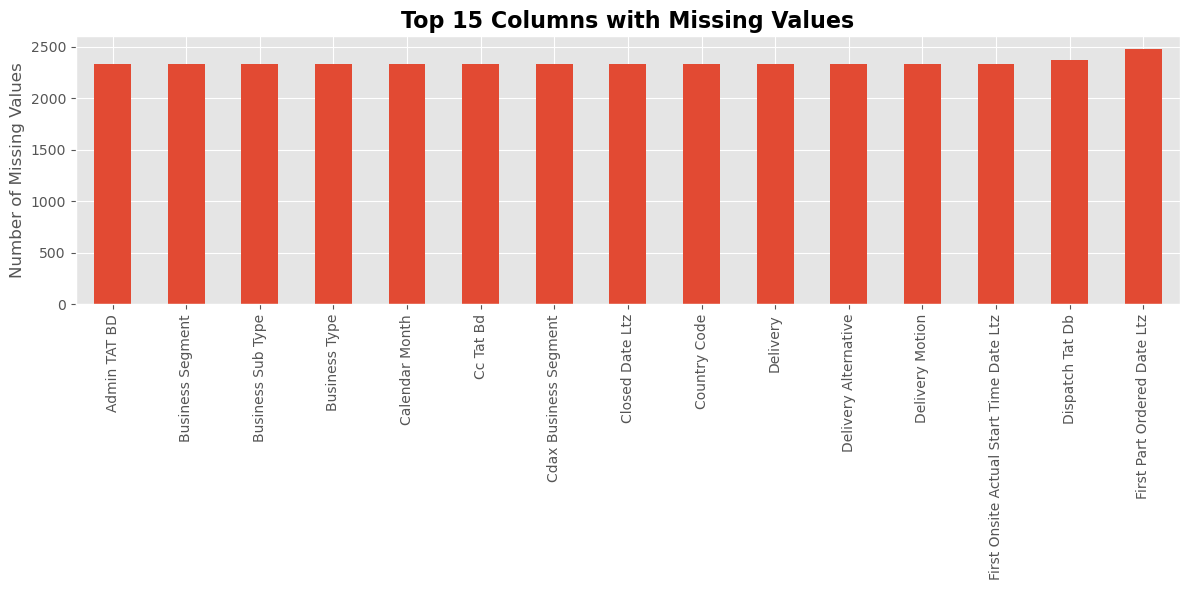

In [33]:
plt.figure(figsize=(12,6))

missing.head(15).plot(kind="bar")

plt.title(
    "Top 15 Columns with Missing Values",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Missing Values")

plt.tight_layout()

plt.show()

In [34]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 2335


In [35]:
print(
    "Duplicate Case IDs :",
    df["Case Id"].duplicated().sum()
)

Duplicate Case IDs : 2336


In [36]:
df.dtypes.value_counts()

object     106
float64     43
Name: count, dtype: int64

In [37]:
object_columns = df.select_dtypes(include="object").columns

print(object_columns)

Index(['Business Segment', 'Business Sub Type', 'Business Type',
       'Cdax Business Segment', 'Closed Date Ltz', 'Country Code', 'Delivery',
       'Delivery Alternative', 'Delivery Motion',
       'First Onsite Actual Start Time Date Ltz',
       ...
       'First Touched Agent Name Case', 'Last Part Ship Plant',
       'Last Part Order Number', 'First Part Ship Plant',
       'First Part Order Number', 'State', 'Field Ops Territory',
       'Product Description', 'Product Category Resume', 'Account Tier'],
      dtype='object', length=106)


In [38]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 1
]

print("Constant columns:")
print(constant_cols)

Constant columns:
['Hpce Area Leader', 'Hpce District Leader', 'Pudo Shipmentid', 'I Last Pudo Ready For Pick Up Date Ltz']


In [39]:
missing_percent = (
    df.isnull().mean()*100
).sort_values(ascending=False)

missing_percent.head(20)

Pudo Shipmentid                           100.000000
Hpce Area Leader                          100.000000
Hpce District Leader                      100.000000
I Last Pudo Ready For Pick Up Date Ltz    100.000000
Last Carrier Drop Date Customer            99.981032
State                                      99.791351
Card Account Name                          99.791351
Cdax Last Actual Pudo Pick Up Date Ltz     97.951442
Account Tier                               76.470030
Last Actual Delivery Date Ltz              42.659332
First Ready For Dispatch Date Ltz          39.425266
Field Ops Territory                        38.249241
Customer Account Name                      37.025797
Last Promised Date Ltz                     25.777693
Logistics Tat Db                           25.445751
Parts Fullfilment Tat Db                   24.506829
Logistics start                            24.497344
Parts fulfillment end                      24.497344
Field Tat Distribution                     24.

In [40]:
identifier_cols = [
    "Case Id",
    "Serial Number",
    "First Valid Wo Id"
]

print(identifier_cols)

['Case Id', 'Serial Number', 'First Valid Wo Id']


In [43]:
leakage_columns = [
    "Response end",
    "Response start",
    "Fix start",
    "Fix end",
    "Field end",
    "E2E end",
    "Field Ola Met Flag",
    "Response Contractual Ola Met Flag",
    "Response Nbd Ola"
]

print("Potential Data Leakage Variables")

for col in leakage_columns:
    if col in df.columns:
        print("-", col)

Potential Data Leakage Variables
- Response end
- Response start
- Fix start
- Fix end
- Field end
- E2E end
- Field Ola Met Flag
- Response Contractual Ola Met Flag
- Response Nbd Ola


### Observation

Several variables represent events occurring after or during the service process (e.g., Response end, Fix end and Response Nbd Ola). These variables could introduce target leakage if included during model training. Therefore, they will be excluded during feature selection to ensure a fair and realistic prediction model.

## Sprint 1 Summary

Completed

✔ Dataset understanding

✔ Exploratory Data Analysis

✔ Data Quality Assessment

Issues identified

• Missing values

• Duplicate records

• Incorrect data types

• Identifier columns

Next Sprint

• Data preprocessing

• Feature engineering

• Baseline model development

# Q2 Data Preprocessing and Baseline Model

## 2.1 Data Cleaning

In [44]:
# Create a copy for preprocessing
clean_df = df.copy()

print(clean_df.shape)

(10544, 149)


### Data Cleaning Summary

The dataset was cleaned through several preprocessing steps before model development. Duplicate service cases were removed using the unique Case ID. Variables that could introduce target leakage were excluded, along with identifier columns that do not contribute predictive information. Columns containing more than 70% missing values were also removed to improve data quality and reduce unnecessary complexity.

In [45]:
print("Before:", clean_df.shape)

clean_df = clean_df.drop_duplicates(subset="Case Id")

print("After :", clean_df.shape)

Before: (10544, 149)
After : (8208, 149)


### Observation

Duplicate service cases were removed based on the unique Case Id to ensure that each record represented one service request.

In [46]:
leakage_columns = [

    "Response end",
    "Response end.1",
    "Response start",

    "Fix start",
    "Fix end",

    "Field start",
    "Field end",

    "E2E start",
    "E2E end",

    "CCC start",
    "CCC end",

    "Admin start",
    "Admin end",

    "Response Nbd Ola",
    "Response Contractual Ola Met Flag",
    "Field Ola Met Flag",
    "Field Ola Target",

]

In [47]:
existing_cols = [
    col for col in leakage_columns
    if col in clean_df.columns
]

clean_df = clean_df.drop(columns=existing_cols)

print("Remaining columns:", clean_df.shape[1])

Remaining columns: 132


In [48]:
identifier_cols = [

    "Case Id",
    "Serial Number",
    "First Valid Wo Id",

    "Customer Name",
    "Customer Account Name",

    "First Part Order Number",
    "Last Part Order Number"

]

identifier_cols = [
    col for col in identifier_cols
    if col in clean_df.columns
]

clean_df = clean_df.drop(columns=identifier_cols)

print(clean_df.shape)

(8208, 125)


In [49]:
missing_percentage = (
    clean_df.isnull().mean() * 100
)

drop_cols = missing_percentage[
    missing_percentage > 70
].index

print(drop_cols)

Index(['Hpce Area Leader', 'Hpce District Leader',
       'Last Carrier Drop Date Customer',
       'Cdax Last Actual Pudo Pick Up Date Ltz', 'Card Account Name',
       'Pudo Shipmentid', 'I Last Pudo Ready For Pick Up Date Ltz', 'State'],
      dtype='object')


In [50]:
clean_df = clean_df.drop(columns=drop_cols)

print(clean_df.shape)

(8208, 117)


In [51]:
remaining_missing = (
    clean_df.isnull()
            .sum()
            .sort_values(ascending=False)
)

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing.head(20)

Account Tier                              5727
Last Actual Delivery Date Ltz             2162
First Ready For Dispatch Date Ltz         1821
Field Ops Territory                       1697
Last Promised Date Ltz                     382
Logistics Tat Db                           347
Parts Fullfilment Tat Db                   248
Parts fulfillment end                      247
Logistics start                            247
Supply Chain Tat Bd 16                     240
SCC end 12                                 240
SCC end                                    240
SCC start                                  240
Supply Chain Tat BD                        240
INX Last Part Pod Date Ltz New             240
INX Sales Order Header Create Date Ltz     240
Field Tat Distribution                     240
Supply Chain Tat Bd 12                     240
Supply Chain Tat Distribution              240
Ssc Nbd Ola Met Flag                       240
dtype: int64

In [52]:
numerical_cols = clean_df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = clean_df.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 34
Categorical columns: 83


In [53]:
# Numerical columns
for col in numerical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Categorical columns
for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

### Observation

Missing values in numerical variables were replaced using median imputation to reduce the influence of extreme values, while missing categorical values were replaced using the mode to preserve the most frequently occurring category.

In [54]:
print(clean_df.isnull().sum().sum())

0


## 2.2 Feature Engineering

### Feature Engineering

Feature engineering was performed to transform the cleaned dataset into a machine-learning-ready format. Categorical variables were encoded into numerical representations, unnecessary date-related variables were removed, and the predictor variables (X) were separated from the target variable (y).

In [55]:
print(clean_df.shape)
clean_df.head()

(8208, 117)


,Admin TAT BD,Business Segment,Business Sub Type,Business Type,Calendar Month,Cc Tat Bd,Cdax Business Segment,Closed Date Ltz,Country Code,Delivery,Delivery Alternative,Delivery Motion,First Onsite Actual Start Time Date Ltz,Dispatch Tat Db,First Part Ordered Date Ltz,First Ready For Dispatch Date Ltz,First Wo Dispatched Date Ltz,Hpce Activer Resource Fwo,Hwpl,Incident Type,Incoming Channel,Last Fixed On Date Date Ltz,Logistics Tat Db,Market Segment,Multiple Interventions Flag,Opened Date Ltz,Order Type,Otc Code,Parts Fullfilment Tat Db,Product,Fix Tat Bd,Response Tat Bd,E2E Resolution BD,Field Tat BD,Supply Chain Tat BD,Admin Tat Distribution,Cc Tat Distribution,Month,Week,Dispatch Tat Distribution,E2E Sit Tat Distribution,Fix Tat Distribution,Response Tat Distribution,Field Tat Distribution,Supply Chain Tat Distribution,Troubleshooting Tat Distribution,Caseid Count,Troubleshooting Tat Bd,Zip Code,Sub Reg1,Sub Reg2,Sub Reg3,Country,Delay Code Categ,Order Type Category,Rdt Tat Bd,Service Offer Identifier,Delay Code,Supplier,Active Resourse Blanks,Service Flag,Owned By Site Name,Product Category Name,Incoming Channel Categ,Global Business Unit,Otc Code Categ,Last Expected Delivery Date Ltz,Last Promised Date Ltz,Last Expected Delivery Date Ltz.1,Last Actual Ship Date Ltz,Last Actual Delivery Date Ltz,Time Zone,Sit 5Bd Flag,Sit 10Bd Flag,Field Ola 2Bd Flag,Field Ola 3Bd Flag,Field Ola Sbd Flag,Ppmd Flag,Pod Shipmentid,Field Contractual Ola Met Flag,Ccc Nbd Ola Met Flag,Ssc 3Bd Ola Met Flag,Ssc Nbd Ola Met Flag,Fix 3Bd Ola Met Flag,Fix Nbd Ola Met Flag,Supply Chain Tat Bd 12,Supply Chain Tat Bd 16,INX Sales Order Header Create Date Ltz,INX Last Part Pod Date Ltz New,Troubleshooting start,Troubleshooting end,SCC start,SCC end,SCC end 12,SCC end 14,SCC end 16,Dispatch start,Dispatch end,Parts fulfillment start,Parts fulfillment end,Logistics start,Logistics end,RDT start,RDT end,First Touched Date Case,Field Contr start,Field Contr TAT BD,Response CT start,Response CT TAT BD,First Touched Agent Name Case,Last Part Ship Plant,First Part Ship Plant,Field Ops Territory,Product Description,Product Category Resume,Account Tier,Wo Count
0,33.0,Printing,Transactional,Transactional,202504.0,0.0,Printing,4/16/2025 22:29:54,MY,Onsite,HP CE Onsite,Onsite,2/26/2025 15:00:00,0.0,2/21/2025 13:16:55,2/21/2025 13:17:59,2/21/2025 13:45:30,MOHAMAD KARIMI BIN HAMAT SHAFIE,30,Print Problem-APJ-Printing,Phone,2/26/2025 16:00:00,1.0,Commercial,0.0,2/21/2025 12:56:54,Break Fix,05K-Extended Warranty,0.0,2Y9H3A,0.0,3.0,3.0,2.0,1.0,5BD+,SBD,25-04,25w16,SBD,3BD,SBD,3BD,2BD,NBD,SBD,1.0,0.0,18300,Greater Asia,South East Asia,Malaysia Brunei,Malaysia,Customer,Break_Fix,1.0,WOSFF0,8-Customer caused Delay,Peopleworks IT Services,1.0,NBD,HP SubK Singapore (APJ),HP DesignJet Large Format Printers,Phone,Large Format,05K-Extend_Wty,2/21/2025 08:00:00,2/24/2025 16:00:00,2/21/2025 08:00:00,2/21/2025 08:00:00,5/15/2025 08:00:00,"(GMT+08:00) Kuala Lumpur, Singapore",1.0,1.0,1.0,1.0,0.0,1.0,3.012886e+09,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2/21/2025 13:47:20,2/23/2025 09:30:00,2/21/2025 12:56:54,2/21/2025 13:17:59,2/21/2025 13:47:20,2/24/2025 08:00:00,2/24/2025 08:00:00,2/24/2025 08:00:00,2/24/2025 08:00:00,2/21/2025 13:17:59,2/21/2025 13:45:30,2/21/2025 13:16:55,2/21/2025 08:00:00,2/21/2025 08:00:00,2/24/2025 8:00:00 AM,2/21/2025 12:56:54,2/24/2025 17:30:00,2/21/2025 4:56:56 AM,2/24/2025 8:00:00 AM,2.0,2/21/2025 1:45:30 PM,3.0,Nurshazlin Halimi,11MY,11MY,Other US,HP DesignJet T950 36-in MFP,PL30,2H25 Tier3,1.0
1,32.0,Personal Systems,Transactional,Transactional,202504.0,3.0,Computing,4/16/2025 11:20:42,MY,Onsite,HP CE Onsite,Onsite,2/13/2025 12:30:00,3.0,1/23/2025 13:54:07,1/23/2025 13:55:01,1/28/2025 15:19:56,Zahin Amsyar Bin Zuraimi,AN,PC Problem-APJ-Computing,ADX_Case,2/27/2025 10:30:11,1.0,Commercial,1.0,1/22/2025 16:36:41,Break Fix,05K-Extended Warranty,3.0,525X3UC,10.0,9.0,22.0,8.0,1.0,5BD+,3BD,25-04,25w16,3BD,10BD+,5BD+,5BD+,5BD+,NBD,SBD,1.0,0.0,14110,Greater Asia,Sout

In [56]:
date_columns = [
    col for col in clean_df.columns
    if "Date" in col
    or "start" in col.lower()
    or "end" in col.lower()
    or "Ltz" in col
]

print(date_columns)

['Calendar Month', 'Closed Date Ltz', 'First Onsite Actual Start Time Date Ltz', 'First Part Ordered Date Ltz', 'First Ready For Dispatch Date Ltz', 'First Wo Dispatched Date Ltz', 'Last Fixed On Date Date Ltz', 'Opened Date Ltz', 'Last Expected Delivery Date Ltz', 'Last Promised Date Ltz', 'Last Expected Delivery Date Ltz.1', 'Last Actual Ship Date Ltz', 'Last Actual Delivery Date Ltz', 'INX Sales Order Header Create Date Ltz', 'INX Last Part Pod Date Ltz New', 'Troubleshooting start', 'Troubleshooting end', 'SCC start', 'SCC end', 'SCC end 12', 'SCC end 14', 'SCC end 16', 'Dispatch start', 'Dispatch end', 'Parts fulfillment start', 'Parts fulfillment end', 'Logistics start', 'Logistics end', 'RDT start', 'RDT end', 'First Touched Date Case', 'Field Contr start', 'Response CT start']


In [57]:
clean_df = clean_df.drop(columns=date_columns)

print(clean_df.shape)

(8208, 84)


In [58]:
target = "Response Tat Bd"

y = clean_df[target]

X = clean_df.drop(columns=[target])

print(X.shape)
print(y.shape)

(8208, 83)
(8208,)


In [59]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(8208, 3441)


### Observation

Categorical variables were transformed into numerical features using one-hot encoding. The first category of each variable was dropped to reduce redundancy and avoid multicollinearity.

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6566, 3441)
(1642, 3441)


### Observation

The dataset was divided into training (80%) and testing (20%) subsets. The training data were used to build the predictive model, while the testing data were reserved for evaluating model performance on unseen data.

## 2.3 Baseline Model Development

A Linear Regression model was selected as the baseline model due to its simplicity, interpretability, and computational efficiency. It serves as an initial benchmark for evaluating model performance before introducing more advanced machine learning algorithms in the next Agile iteration.

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [96]:
leakage_keywords = [
    "Response CT",
    "Distribution",
    "Ola",
    "Flag"
]

leakage_cols = [
    col for col in X.columns
    if any(keyword.lower() in col.lower() for keyword in leakage_keywords)
]

X_final = X.drop(columns=leakage_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42
)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("=" * 50)
print("Baseline Linear Regression After Leakage Removal")
print("=" * 50)
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Baseline Linear Regression After Leakage Removal
MAE  : 0.6683
RMSE : 1.5702
R²   : 0.8456


### Observation

The Linear Regression model was used as the baseline predictive model for engineer response time. Although it provides a simple and interpretable benchmark, the prediction results are expected to have limitations due to the linear assumptions of the algorithm. More advanced machine learning models will be explored in Sprint 3 to improve prediction accuracy.

### Model Refinement

The initial baseline model produced unrealistically high predictive performance, indicating the presence of target leakage. Further investigation identified response-related distribution variables and operational attributes that indirectly contained information about the target variable.

These leakage-related features were removed before retraining the model. After refinement, the Linear Regression model achieved more realistic performance and serves as the official baseline for comparison with improved machine learning models in the next Agile sprint.

In [97]:
# Sprint 3: Improved Model using Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Sprint 3 Improved Model: Random Forest Regressor")
print("MAE:", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²:", round(rf_r2, 4))

Sprint 3 Improved Model: Random Forest Regressor
MAE: 0.3292
RMSE: 1.2133
R²: 0.9078


                                                Feature  Importance
12                                   Field Contr TAT BD    0.591716
4                              Parts Fullfilment Tat Db    0.279228
2                                       Dispatch Tat Db    0.009235
11                               Supply Chain Tat Bd 16    0.008035
5                                   Supply Chain Tat BD    0.005977
10                               Supply Chain Tat Bd 12    0.005902
131                                             Hwpl_BO    0.004436
1                                             Cc Tat Bd    0.003720
2746  Product Description_HP EB840G11 U5-125H 14 16G...    0.003189
3                                      Logistics Tat Db    0.002749


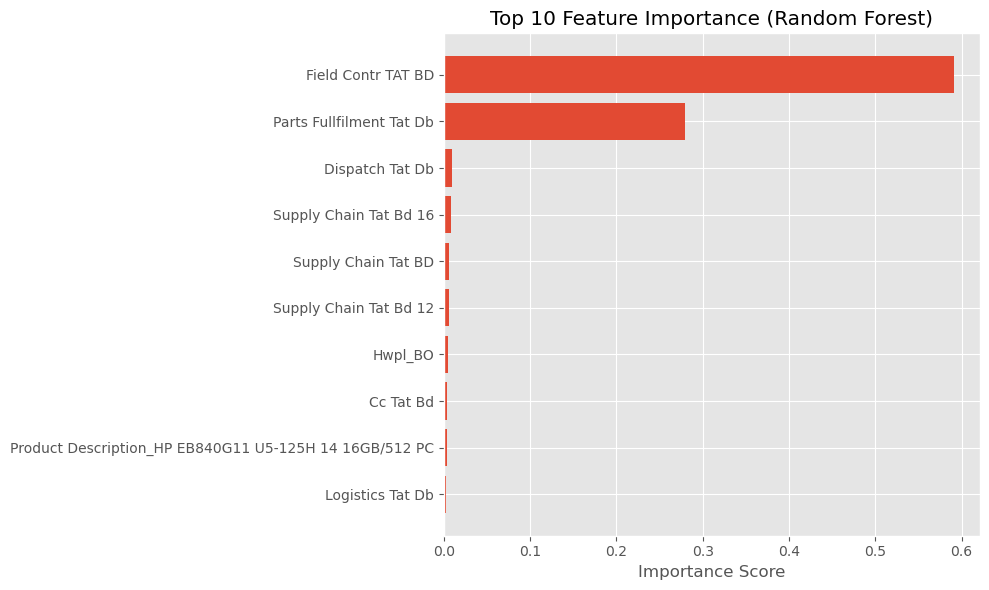

In [98]:
# Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [99]:
# Random Forest Evaluation Summary

rf_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Random Forest": [
        round(rf_mae, 4),
        round(rf_rmse, 4),
        round(rf_r2, 4)
    ]
})

display(rf_results)

,Metric,Random Forest
0,MAE,0.3292
1,RMSE,1.2133
2,R²,0.9078


In [100]:
comparison = pd.DataFrame({
    "Aspect": [
        "Model Used",
        "MAE",
        "RMSE",
        "R²",
        "Improvement Introduced"
    ],
    "Sprint 2": [
        "Linear Regression",
        0.6683,
        1.5702,
        0.8456,
        "Baseline model"
    ],
    "Sprint 3": [
        "Random Forest",
        0.3292,
        1.2133,
        0.9078,
        "Alternative ensemble algorithm"
    ]
})

display(comparison)

,Aspect,Sprint 2,Sprint 3
0,Model Used,Linear Regression,Random Forest
1,MAE,0.6683,0.3292
2,RMSE,1.5702,1.2133
3,R²,0.8456,0.9078
4,Improvement Introduced,Baseline model,Alternative ensemble algorithm


In [101]:
improvement = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Sprint 2": [0.6683, 1.5702, 0.8456],
    "Sprint 3": [0.3292, 1.2133, 0.9078]
})

improvement["Difference"] = improvement["Sprint 3"] - improvement["Sprint 2"]
improvement["% Change"] = (
    (improvement["Sprint 3"] - improvement["Sprint 2"])
    / improvement["Sprint 2"] * 100
).round(2)

display(improvement)

,Metric,Sprint 2,Sprint 3,Difference,% Change
0,MAE,0.6683,0.3292,-0.3391,-50.74
1,RMSE,1.5702,1.2133,-0.3569,-22.73
2,R²,0.8456,0.9078,0.0622,7.36


In [107]:
# Q3(a): Final Automated Data Validation Script

validated_df = clean_df.drop_duplicates()

def validate_dataset(df):
    print("========== DATA VALIDATION REPORT ==========\n")

    missing = df.isnull().sum().sum()
    print(f"Missing Values: {missing}")

    duplicates = df.duplicated().sum()
    print(f"Duplicate Rows: {duplicates}")

    if "Response Tat Bd" in df.columns:
        negative = (df["Response Tat Bd"] < 0).sum()
        print(f"Negative Response Tat Bd: {negative}")

    print("\nValidation Completed.")

validate_dataset(validated_df)

========== DATA VALIDATION REPORT ==========

Missing Values: 0
Duplicate Rows: 0
Negative Response Tat Bd: 0

Validation Completed.
